# 📰 Learning to Read Politics
## An Investigation into Ideological Structure in Transformer Representational Spaces

Do transformer models (BERT) encode political ideology as linearly seperable, as a single geometric direction within their internal representations, and how much of the representation space is explained by direction?

# Setup

- Installs
- Imports

In [3]:
# ---------
# Installs
# ---------

!pip install ftfy
!pip install transformers -q

print("✅ Installed packages")

✅ Installed packages


In [9]:
# --------
# Imports
# --------

import os
from datasets import load_dataset
from urllib.parse import urlparse
import kagglehub
import pandas as pd
from google.colab import files
from sklearn.model_selection import train_test_split
from ftfy import fix_text
from transformers import BertTokenizer, BertModel
import torch
import torch.nn as nn
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import torch.optim as optim
from sklearn.metrics import confusion_matrix
from collections import Counter
from scipy.spatial.distance import pdist, squareform
from sklearn.manifold import TSNE
import seaborn as sns
from sklearn.decomposition import PCA
from scipy.stats import wasserstein_distance
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
import warnings
import logging
from transformers import logging as hf_logging

print("✅ Imported packages")

✅ Imported packages


# Data Collection

In [6]:
path = kagglehub.dataset_download("gandpablo/news-articles-for-political-bias-classification")


news = pd.read_csv(
    f"{path}/bias_clean.csv",
    encoding="latin1",
    on_bad_lines="skip",
    low_memory=True,
    nrows=100000
)

allowed_topics = [
    "elections",
    "economy-and-jobs",
    "defense-and-security",
    "immigration",
    "donald-trump"
]

news = news[news['topic'].isin(allowed_topics)]

def stratified_sample_total(df, topic_col='topic', bias_col='bias', total_n=1250, random_state=42):
    topics = df[topic_col].unique()
    n_topics = len(topics)
    n_per_topic = total_n // n_topics

    all_biases_in_df = df[bias_col].unique()
    n_all_biases = len(all_biases_in_df)

    sampled_list = []

    for topic, group in df.groupby(topic_col):
        total_in_topic = len(group)

        if total_in_topic <= n_per_topic:

            sampled_list.append(group)
        else:
            target_n_per_bias = n_per_topic // n_all_biases

            n_samples_per_bias_dict = {}
            for bias_cat in all_biases_in_df:
                available_count = len(group[group[bias_col] == bias_cat])
                n_samples_per_bias_dict[bias_cat] = min(available_count, target_n_per_bias)


            current_total_sampled_for_topic = sum(n_samples_per_bias_dict.values())
            remaining_for_topic = n_per_topic - current_total_sampled_for_topic


            if remaining_for_topic > 0:

                eligible_biases_for_extra = [
                    bias_cat for bias_cat in all_biases_in_df
                    if len(group[group[bias_col] == bias_cat]) > n_samples_per_bias_dict[bias_cat]
                ]

                idx = 0
                while remaining_for_topic > 0 and eligible_biases_for_extra:
                    bias_to_add_to = eligible_biases_for_extra[idx % len(eligible_biases_for_extra)]


                    if len(group[group[bias_col] == bias_to_add_to]) > n_samples_per_bias_dict[bias_to_add_to]:
                        n_samples_per_bias_dict[bias_to_add_to] += 1
                        remaining_for_topic -= 1
                    else:
                        eligible_biases_for_extra.pop(idx % len(eligible_biases_for_extra))
                        if eligible_biases_for_extra:
                            idx = idx % len(eligible_biases_for_extra)
                        else:
                            idx = 0

                    if eligible_biases_for_extra:
                        idx += 1
                    else:
                        break

            n_samples_per_bias = pd.Series(n_samples_per_bias_dict)

            sampled_topic = pd.concat([
                group[group[bias_col] == bias].sample(n=n_samples_per_bias[bias], random_state=random_state)
                for bias in n_samples_per_bias.index if n_samples_per_bias[bias] > 0
            ])
            sampled_list.append(sampled_topic)

    return pd.concat(sampled_list).reset_index(drop=True)

sampled_news = stratified_sample_total(news, total_n=1250)

sampled_news["strata"] = (
    sampled_news["topic"].astype(str) + "_" + sampled_news["bias"].astype(str)
)

train, temp = train_test_split(
    sampled_news,
    test_size=0.3,
    stratify=sampled_news["strata"],
    random_state=42
)

val, test = train_test_split(
    temp,
    test_size=0.5,
    stratify=temp["strata"],
    random_state=42
)

train = train.drop(columns=["strata"])
val = val.drop(columns=["strata"])
test = test.drop(columns=["strata"])

def is_clean_text(text):
    if not isinstance(text, str):
        return False

    weird_ratio = sum(1 for c in text if ord(c) > 127) / max(len(text), 1)

    if len(text.split()) < 50:
        return False

    if weird_ratio > 0.3:
        return False

    return True

train = train[train["page_text"].apply(is_clean_text)]
val   = val[val["page_text"].apply(is_clean_text)]
test  = test[test["page_text"].apply(is_clean_text)]

train["page_text"] = train["page_text"].apply(fix_text)
val["page_text"]   = val["page_text"].apply(fix_text)
test["page_text"]  = test["page_text"].apply(fix_text)

os.makedirs("data/processed", exist_ok=True)

train.to_csv("data/processed/train.csv", index=False)
val.to_csv("data/processed/val.csv", index=False)
test.to_csv("data/processed/test.csv", index=False)

sampled_news.drop(columns=["strata"]).to_csv(
    "data/processed/sampled_news.csv",
    index=False
)

print("✅ Saved dataset splits")
print(f"Train: {len(train)} samples")
print(f"Validation: {len(val)} samples")
print(f"Test: {len(test)} samples")

Using Colab cache for faster access to the 'news-articles-for-political-bias-classification' dataset.
✅ Saved dataset splits
Train: 873 samples
Validation: 187 samples
Test: 188 samples


# Frozen BERT

- We take pretrained, or "frozen", embeddings from BERT base model. This means that we do not train the model.
- Then we train a linear classifier, or probe, on the last layer embeddings.
- This classifier is a fixed linear boundary that best seperates ideology labels (left, leaning-left, center, leaning-right, right)

In [11]:
warnings.filterwarnings("ignore")
hf_logging.set_verbosity_error()
logging.getLogger("huggingface_hub").setLevel(logging.ERROR)
os.environ["TOKENIZERS_PARALLELISM"] = "false"

model_name = "bert-base-uncased"
tokenizer = BertTokenizer.from_pretrained(model_name)
frozen_bert = BertModel.from_pretrained(model_name,
                                        output_hidden_states = True,
                                        output_attentions = True)
frozen_bert.eval()

print(f"✅ BERT model '{model_name}' loaded successfully.")

def tokenize(df):
  return tokenizer(df['page_text'].tolist(),
                   padding=True,
                   truncation=True,
                   max_length=512,
                   return_tensors="pt")

train_tok = tokenize(train)
val_tok = tokenize(val)
test_tok = tokenize(test)

def get_bert_embeddings(text_list, batch_size=16):
    embeddings = []

    for i in range(0, len(text_list), batch_size):
        batch_texts = text_list[i:i+batch_size]
        tokens = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=128,
            return_tensors='pt'
        )
        with torch.no_grad():
            outputs = frozen_bert(**tokens)
            batch_embeddings = outputs.pooler_output
        embeddings.append(batch_embeddings)

    embeddings = torch.cat(embeddings, dim=0)
    return embeddings

X_train_emb = get_bert_embeddings(train['page_text'].tolist())
X_val_emb   = get_bert_embeddings(val['page_text'].tolist())
X_test_emb  = get_bert_embeddings(test['page_text'].tolist())

# Bias Classifier

bias_label_map = {
    "left": 0,
    "leaning-left": 1,
    "center": 2,
    "leaning-right": 3,
    "right": 4
}

train['label'] = train['bias'].map(bias_label_map)
val['label'] = val['bias'].map(bias_label_map)
test['label'] = test['bias'].map(bias_label_map)

y_train_bias = torch.tensor(train['label'].values)
y_val_bias = torch.tensor(val['label'].values)
y_test_bias = torch.tensor(test['label'].values)

bias_num_labels = len(bias_label_map)

bias_classifier = nn.Linear(768, bias_num_labels)
criterion_bias = nn.CrossEntropyLoss()
optimizer_bias = optim.Adam(bias_classifier.parameters(), lr=2e-5)

bias_train_acc, bias_val_acc = [], []
bias_train_prec, bias_val_prec = [], []
bias_train_rec, bias_val_rec = [], []
bias_train_f1, bias_val_f1 = [], []

for epoch in range(3):
    bias_classifier.train()

    optimizer_bias.zero_grad()
    train_outputs = bias_classifier(X_train_emb)
    train_loss = criterion_bias(train_outputs, y_train_bias)
    train_loss.backward()
    optimizer_bias.step()

    train_preds = train_outputs.argmax(dim=1)

    bias_train_acc.append(accuracy_score(y_train_bias.numpy(), train_preds.detach().numpy()))
    bias_train_prec.append(precision_score(y_train_bias.numpy(), train_preds.detach().numpy(), average='macro', zero_division=0))
    bias_train_rec.append(recall_score(y_train_bias.numpy(), train_preds.detach().numpy(), average='macro', zero_division=0))
    bias_train_f1.append(f1_score(y_train_bias.numpy(), train_preds.detach().numpy(), average='macro', zero_division=0))

    bias_classifier.eval()
    with torch.no_grad():
        val_outputs = bias_classifier(X_val_emb)
        val_preds = val_outputs.argmax(dim=1)

    bias_val_acc.append(accuracy_score(y_val_bias.numpy(), val_preds.numpy()))
    bias_val_prec.append(precision_score(y_val_bias.numpy(), val_preds.numpy(), average='macro', zero_division=0))
    bias_val_rec.append(recall_score(y_val_bias.numpy(), val_preds.numpy(), average='macro', zero_division=0))
    bias_val_f1.append(f1_score(y_val_bias.numpy(), val_preds.numpy(), average='macro', zero_division=0))

    print(
        f"[Bias] Epoch {epoch+1}/3 | "
        f"Train Acc: {bias_train_acc[-1]:.3f} | "
        f"Val Acc: {bias_val_acc[-1]:.3f}"
    )

bias_classifier.eval()

with torch.no_grad():
    test_preds = bias_classifier(X_test_emb).argmax(dim=1)

test_acc_bias = accuracy_score(y_test_bias.numpy(), test_preds.numpy())
test_prec_bias = precision_score(y_test_bias.numpy(), test_preds.numpy(), average='macro', zero_division=0)
test_rec_bias = recall_score(y_test_bias.numpy(), test_preds.numpy(), average='macro', zero_division=0)
test_f1_bias = f1_score(y_test_bias.numpy(), test_preds.numpy(), average='macro', zero_division=0)

bias_metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Value': [test_acc_bias, test_prec_bias, test_rec_bias, test_f1_bias]
})
print("\nBias Classifier Test Metrics:")
display(bias_metrics_df)

# Topic Classifier

topic_label_map = {label: i for i, label in enumerate(train['topic'].unique())}

train['label'] = train['topic'].map(topic_label_map)
val['label'] = val['topic'].map(topic_label_map)
test['label'] = test['topic'].map(topic_label_map)

y_train_topic = torch.tensor(train['label'].values)
y_val_topic = torch.tensor(val['label'].values)
y_test_topic = torch.tensor(test['label'].values)

topic_train_acc, topic_val_acc = [], []
topic_train_prec, topic_val_prec = [], []
topic_train_rec, topic_val_rec = [], []
topic_train_f1, topic_val_f1 = [], []

topic_num_labels = len(topic_label_map)

topic_classifier = nn.Linear(768, topic_num_labels)
criterion_topic = nn.CrossEntropyLoss()
optimizer_topic = optim.Adam(topic_classifier.parameters(), lr=2e-5)

for epoch in range(3):
    topic_classifier.train()

    optimizer_topic.zero_grad()
    train_outputs = topic_classifier(X_train_emb)
    train_loss = criterion_topic(train_outputs, y_train_topic)
    train_loss.backward()
    optimizer_topic.step()

    train_preds = train_outputs.argmax(dim=1)

    topic_train_acc.append(accuracy_score(y_train_topic.numpy(), train_preds.detach().numpy()))
    topic_train_prec.append(precision_score(y_train_topic.numpy(), train_preds.detach().numpy(), average='macro', zero_division=0))
    topic_train_rec.append(recall_score(y_train_topic.numpy(), train_preds.detach().numpy(), average='macro', zero_division=0))
    topic_train_f1.append(f1_score(y_train_topic.numpy(), train_preds.detach().numpy(), average='macro', zero_division=0))

    topic_classifier.eval()
    with torch.no_grad():
        val_outputs = topic_classifier(X_val_emb)
        val_preds = val_outputs.argmax(dim=1)

    topic_val_acc.append(accuracy_score(y_val_topic.numpy(), val_preds.numpy()))
    topic_val_prec.append(precision_score(y_val_topic.numpy(), val_preds.numpy(), average='macro', zero_division=0))
    topic_val_rec.append(recall_score(y_val_topic.numpy(), val_preds.numpy(), average='macro', zero_division=0))
    topic_val_f1.append(f1_score(y_val_topic.numpy(), val_preds.numpy(), average='macro', zero_division=0))

    print(
    f"[Topic] Epoch {epoch+1}/3 | "
    f"Train Acc: {topic_train_acc[-1]:.3f} | "
    f"Val Acc: {topic_val_acc[-1]:.3f}"
)

topic_classifier.eval()

with torch.no_grad():
    test_preds = topic_classifier(X_test_emb).argmax(dim=1)

test_acc_topic = accuracy_score(y_test_topic.numpy(), test_preds.numpy())
test_prec_topic = precision_score(y_test_topic.numpy(), test_preds.numpy(), average='macro', zero_division=0)
test_rec_topic = recall_score(y_test_topic.numpy(), test_preds.numpy(), average='macro', zero_division=0)
test_f1_topic = f1_score(y_test_topic.numpy(), test_preds.numpy(), average='macro', zero_division=0)

topic_metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Value': [test_acc_topic, test_prec_topic, test_rec_topic, test_f1_topic]
})
print("\nTopic Classifier Test Metrics:")
display(topic_metrics_df)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

✅ BERT model 'bert-base-uncased' loaded successfully.
[Bias] Epoch 1/3 | Train Acc: 0.210 | Val Acc: 0.198
[Bias] Epoch 2/3 | Train Acc: 0.212 | Val Acc: 0.198
[Bias] Epoch 3/3 | Train Acc: 0.213 | Val Acc: 0.198

Bias Classifier Test Metrics:


,Metric,Value
0,Accuracy,0.202128
1,Precision,0.107551
2,Recall,0.205714
3,F1 Score,0.078416


[Topic] Epoch 1/3 | Train Acc: 0.153 | Val Acc: 0.134
[Topic] Epoch 2/3 | Train Acc: 0.153 | Val Acc: 0.128
[Topic] Epoch 3/3 | Train Acc: 0.157 | Val Acc: 0.128

Topic Classifier Test Metrics:


,Metric,Value
0,Accuracy,0.138298
1,Precision,0.154163
2,Recall,0.135628
3,F1 Score,0.085050


# Layer-wise Probing - Frozen

- We conduct layer-wise probing with the same linear classifier, which again is trained entirely independently of the model itself.
- Specifically, we continue to freeze the neural network, extract hidden representations, and train a probe that iterates over each layer on top of them.
- At every level, we take the features $H_k$ from that layer and try to predict the correct ideological labels $y$ using our classifier...
$$
f_k: H_k \rightarrow [0,1]^D
$$

$$
h_k \rightarrow softmax(Wh_k+b)
$$
- BERT base has 12 layers.
- Probes are thought to be monotonic, meaning we should ould see that the deeper embeddings go within the transformer structure, the higher the degree of linear separability should be. As in, the decision boundaries between the classes should be more acccurate.
- We examine performance with accuracy, precision, recall, and f1.


Layer-wise Bias Classification Metrics:


,Layer,Accuracy,Precision,Recall,F1 Score
0,0,0.212766,0.042553,0.200000,0.070175
1,1,0.287234,0.297782,0.287428,0.287723
2,2,0.265957,0.264833,0.267493,0.264043
3,3,0.308511,0.311684,0.307451,0.307949
4,4,0.335106,0.331895,0.334060,0.331735
5,5,0.356383,0.364321,0.356791,0.357413
6,6,0.335106,0.336196,0.335598,0.334676
7,7,0.345745,0.342105,0.343403,0.340858
8,8,0.313830,0.308608,0.310959,0.308406
9,9,0.335106,0.343500,0.336833,0.336749



Layer-wise Topic Classification Metrics:


,Layer,Accuracy,Precision,Recall,F1 Score
0,0,0.191489,0.038298,0.200000,0.064286
1,1,0.765957,0.769756,0.766556,0.767673
2,2,0.776596,0.789058,0.775118,0.777967
3,3,0.797872,0.807575,0.797895,0.800291
4,4,0.750000,0.755363,0.751734,0.751340
5,5,0.771277,0.784906,0.771549,0.775358
6,6,0.739362,0.753954,0.740390,0.743045
7,7,0.723404,0.731679,0.724983,0.722572
8,8,0.638298,0.644419,0.639739,0.639324
9,9,0.643617,0.646150,0.645976,0.643528


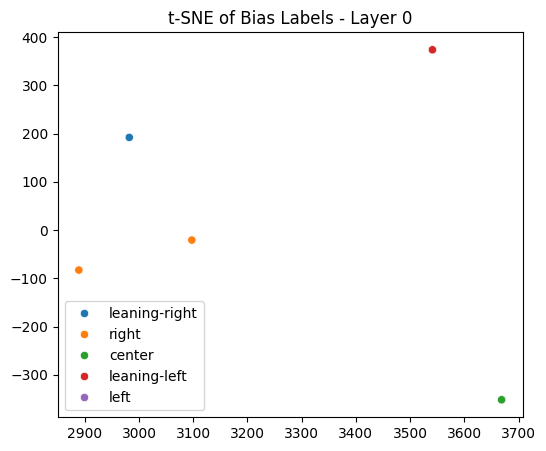

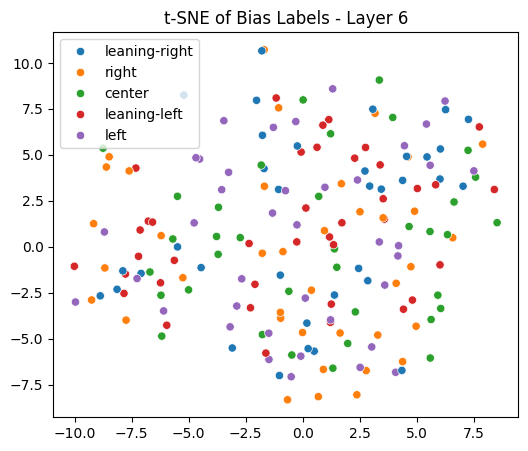

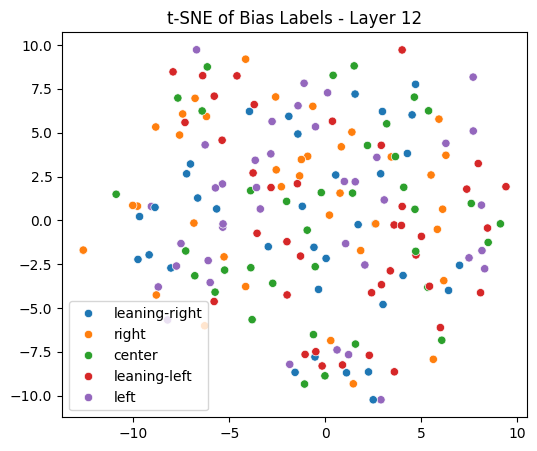

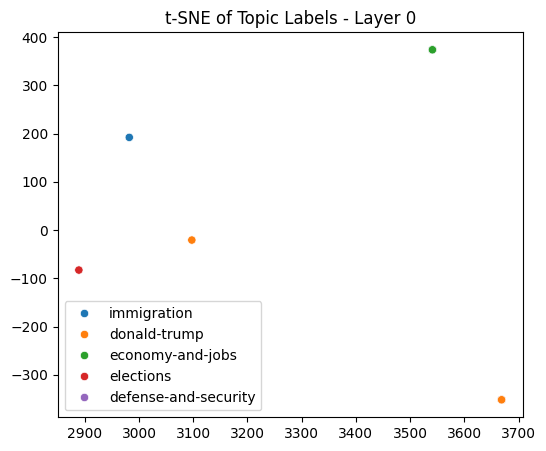

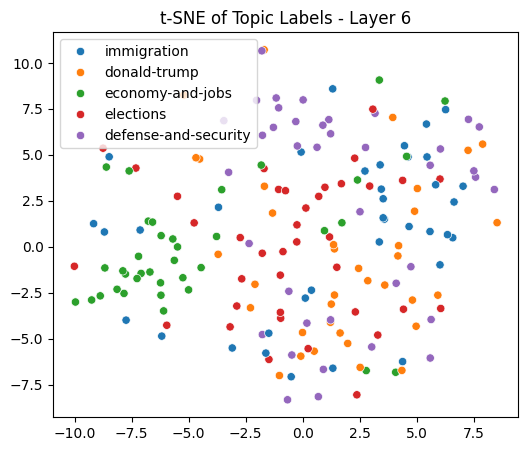

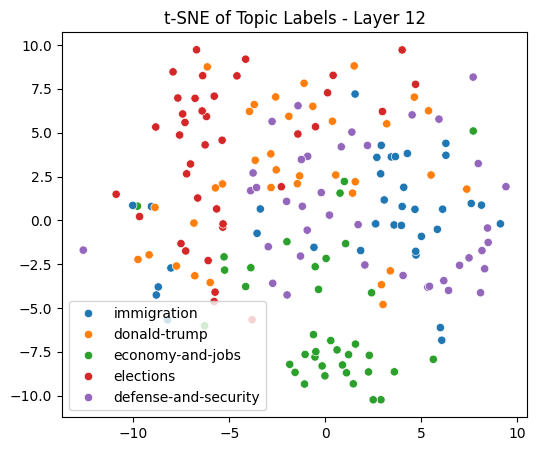

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
frozen_bert = frozen_bert.to(device)

y_train_bias  = train['bias'].values
y_val_bias    = val['bias'].values
y_test_bias   = test['bias'].values

y_train_topic = train['topic'].values
y_val_topic   = val['topic'].values
y_test_topic  = test['topic'].values

def extract_cls_embeddings(texts, frozen_bert, tokenizer, batch_size=16):
    layer_outputs = [[] for _ in range(13)]

    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]

        inputs = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=512,
            return_tensors="pt"
        ).to(device)

        with torch.no_grad():
            outputs = frozen_bert(**inputs)

        for layer_idx, layer in enumerate(outputs.hidden_states):
            cls = layer[:, 0, :].cpu()
            layer_outputs[layer_idx].append(cls)

        del inputs, outputs
        torch.cuda.empty_cache()

    return [torch.cat(layers, dim=0).numpy() for layers in layer_outputs]

train_layers = extract_cls_embeddings(train['page_text'].tolist(), frozen_bert, tokenizer)
val_layers   = extract_cls_embeddings(val['page_text'].tolist(), frozen_bert, tokenizer)
test_layers  = extract_cls_embeddings(test['page_text'].tolist(), frozen_bert, tokenizer)

layer_f1_bias = []
layer_acc_bias = []
layer_prec_bias = []
layer_rec_bias = []

layer_f1_topic = []
layer_acc_topic = []
layer_prec_topic = []
layer_rec_topic = []


for layer in range(13):
    X_tr = train_layers[layer]
    X_te = test_layers[layer]

    scaler = StandardScaler()
    X_tr = scaler.fit_transform(X_tr)
    X_te = scaler.transform(X_te)

    clf_bias  = LogisticRegression(max_iter=1000, class_weight="balanced")
    clf_topic = LogisticRegression(max_iter=1000, class_weight="balanced")

    clf_bias.fit(X_tr, y_train_bias)
    clf_topic.fit(X_tr, y_train_topic)

    preds_bias  = clf_bias.predict(X_te)
    preds_topic = clf_topic.predict(X_te)

    f1_bias  = f1_score(y_test_bias, preds_bias, average="macro", zero_division=0)
    acc_bias = accuracy_score(y_test_bias, preds_bias,)
    prec_bias = precision_score(y_test_bias, preds_bias, average="macro", zero_division=0)
    rec_bias = recall_score(y_test_bias, preds_bias, average="macro", zero_division=0)

    f1_topic = f1_score(y_test_topic, preds_topic, average="macro", zero_division=0)
    acc_topic = accuracy_score(y_test_topic, preds_topic)
    prec_topic = precision_score(y_test_topic, preds_topic, average="macro", zero_division=0)
    rec_topic = recall_score(y_test_topic, preds_topic, average="macro", zero_division=0)

    layer_f1_bias.append(f1_bias)
    layer_acc_bias.append(acc_bias)
    layer_prec_bias.append(prec_bias)
    layer_rec_bias.append(rec_bias)

    layer_f1_topic.append(f1_topic)
    layer_acc_topic.append(acc_topic)
    layer_prec_topic.append(prec_topic)
    layer_rec_topic.append(rec_topic)

layer_bias_metrics_df = pd.DataFrame({
    'Layer': range(13),
    'Accuracy': layer_acc_bias,
    'Precision': layer_prec_bias,
    'Recall': layer_rec_bias,
    'F1 Score': layer_f1_bias
})
print("\nLayer-wise Bias Classification Metrics:")
display(layer_bias_metrics_df)

layer_topic_metrics_df = pd.DataFrame({
    'Layer': range(13),
    'Accuracy': layer_acc_topic,
    'Precision': layer_prec_topic,
    'Recall': layer_rec_topic,
    'F1 Score': layer_f1_topic
})
print("\nLayer-wise Topic Classification Metrics:")
display(layer_topic_metrics_df)

# t-SNE
tsne_layers = [0, 6, 12]
for layer_idx in tsne_layers:
    X_tr = val_layers[layer_idx]
    tsne = TSNE(n_components=2, perplexity=30, random_state=42)
    tsne_emb = tsne.fit_transform(X_tr)

    plt.figure(figsize=(6,5))
    sns.scatterplot(x=tsne_emb[:,0], y=tsne_emb[:,1], hue=y_val_bias, palette="tab10")
    plt.title(f"t-SNE of Bias Labels - Layer {layer_idx}")
    plt.show()

tsne_results = {}

for layer_idx in [0,6,12]:

    X_tr = val_layers[layer_idx]

    tsne = TSNE(
        n_components=2,
        perplexity=30,
        random_state=42
    )

    tsne_results[layer_idx] = tsne.fit_transform(X_tr)
    tsne_emb = tsne_results[layer_idx]

    plt.figure(figsize=(6,5))
    sns.scatterplot(x=tsne_emb[:,0], y=tsne_emb[:,1], hue=y_val_topic, palette="tab10")
    plt.title(f"t-SNE of Topic Labels - Layer {layer_idx}")
    plt.show()

# Directional Analysis
- The $W$ features is the probe weight that is learned by the classifier. It represents the direction orthogonal to some decision boundary for ideological classes.
- Eseentially, the boundary seperates classes, and direction tell us which "side" each class sits of that boundary.
- This weight vector is learned independently on top of frozen embeddings extracted from each layer of the encoder.
- If we take the most extreme classes (left & right), the difference of their means (or average embedding) provides us with an approximation of the direction that best seperates the two groups in the embedding space...
$$
v = \mu_L - \mu_R
$$

where $v$ represents an axis that seperates where embeddings tend to cluster together

- Since we have both a point (embedding) and a direction (vector of difference of means), we can compute projections onto the direction vector. This tells us where along the direction axis an embedding sits...
$$
s = v^Tx
$$

- We normalize direction with L2 norm to isoloate "structure" of ideological axis, and ignore magnitude.

In [14]:
direction_results = []

label_order = [
    "left",
    "leaning-left",
    "center",
    "leaning-right",
    "right"
]

for layer_idx in range(13):

    X = test_layers[layer_idx]

    left_mean = X[y_test_bias == "left"].mean(axis=0)
    right_mean = X[y_test_bias == "right"].mean(axis=0)

    ideology_direction = right_mean - left_mean

    ideology_direction = (
        ideology_direction /
        np.linalg.norm(ideology_direction)
    )

    projections = X @ ideology_direction

    layer_result = {
        "layer": layer_idx
    }

    for label in label_order:

        idx = np.where(y_test_bias == label)[0]

        layer_result[label] = projections[idx].mean()

    direction_results.append(layer_result)

direction_df = pd.DataFrame(direction_results)

print(direction_df)

    layer      left  leaning-left    center  leaning-right     right
0       0 -4.851288     -4.851288 -4.851288      -4.851288 -4.851288
1       1 -0.037531      0.005730  0.034429       0.064281  0.070319
2       2  0.087160      0.211992  0.220893       0.269547  0.350730
3       3  0.852519      0.938880  0.965593       1.036798  1.073288
4       4  0.966566      1.087525  1.114738       1.200393  1.318526
5       5 -0.018687      0.119641  0.126027       0.201204  0.379828
6       6 -0.561835     -0.004177 -0.223757      -0.148700  0.095511
7       7 -1.391969     -0.773664 -0.927126      -0.726729 -0.500645
8       8 -1.109513     -0.629437 -0.648761      -0.754814 -0.247320
9       9  0.190623      0.655718  0.780148       0.823825  1.314669
10     10 -0.189272      0.324699  0.612725       0.438964  1.430734
11     11  0.252319      0.756760  0.952492       0.821763  1.817601
12     12  0.173721      0.922691  0.823103       0.814782  1.833117


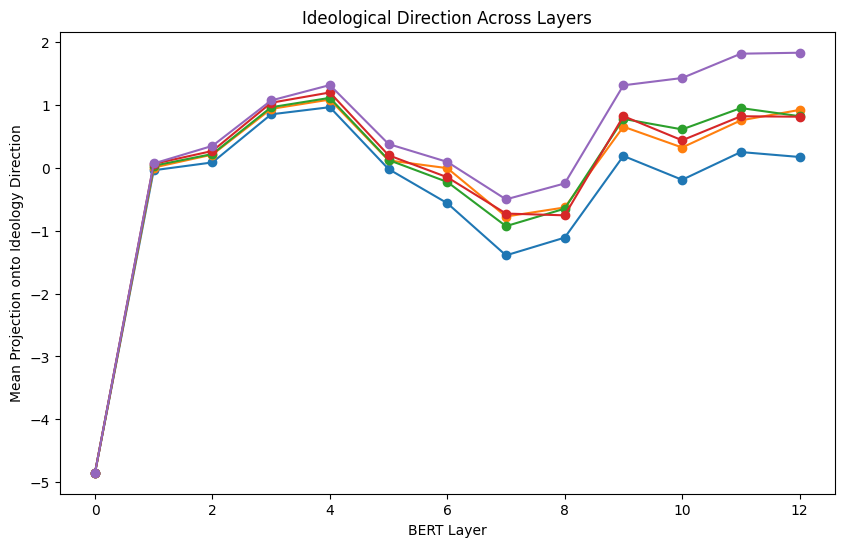

In [15]:
# -----------
# Visualize!
# -----------

fig, ax = plt.subplots(figsize=(10,6))

for label in label_order:
    ax.plot(
        direction_df["layer"],
        direction_df[label],
        marker="o",
        label=label
    )

ax.set_xlabel("BERT Layer")
ax.set_ylabel("Mean Projection onto Ideology Direction")
ax.set_title("Ideological Direction Across Layers")

plt.show()

# Ideological Axis

- We look at one direction axis from the final layer of the encoder.
- We take the scalar ideology score...

$$
s = v^Tx
$$

- Then, concatenate all the ideology groups together and collaspe onto a horizontal axis.
- Each point represents one text, and their position on the x-axis is the ideology project score


In [17]:
p_left = projections[y_test_bias == 'left']
p_ll = projections[y_test_bias == 'leaning-left']
p_center = projections[y_test_bias == 'center']
p_lr = projections[y_test_bias == 'leaning-right']
p_right = projections[y_test_bias == 'right']

all_p = np.concatenate([p_left, p_ll, p_center, p_lr, p_right])
all_labels = np.concatenate([
    ["left"]*len(p_left),
    ["leaning-left"]*len(p_ll),
    ["center"]*len(p_center),
    ["leaning-right"]*len(p_lr),
    ["right"]*len(p_right)
])

encoded_labels = np.array([bias_label_map[label] for label in all_labels])

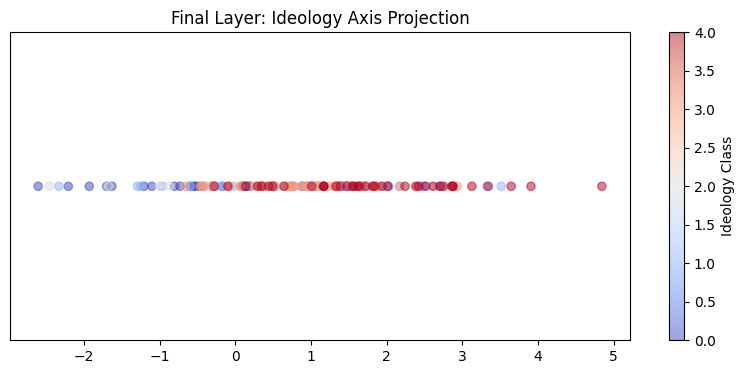

In [18]:
# -----------
# Visualize!
# -----------

plt.figure(figsize=(10,4))

plt.scatter(
    all_p,
    np.zeros_like(all_p),
    c=encoded_labels,
    cmap="coolwarm",
    alpha=0.5
)

plt.yticks([])
plt.title("Final Layer: Ideology Axis Projection")

plt.colorbar(label="Ideology Class")
plt.show()

# Geometric Structure
- Next, we map embedding space onto ideology vs non-ideology structure.
- We use Principal Component Analysis (PCA), which reduces the # of features while keeping the most information. Basically, it selects the top directions with the highest eigenvalues (importance).
- We use the `pca` function from the `sklearn` package, but will explain the basics of how pca works:
  - Standardize embedding dimensions to maintain scale
  $$
  Z = \frac{x - \mu}{\sigma}
  $$
  - Calculate covariance matrix to see how embeddings relate to each other
  - Find 2 principal components:
    - PC1: direction of maximum variance
    - PC2: next best direction
- We do this process twice, once with original embeddings and once void of ideology information.
- This allows us to compare how ideology is encoded versus other encoded features (e.g. topic structure, writing style, semantic clusters)
- Essentially, we are seeing if structure is maintained without an ideology component.







In [20]:
v = ideology_direction / np.linalg.norm(ideology_direction)
y_labels_numeric = np.array([bias_label_map[label] for label in y_test_bias])

pca = PCA(n_components=2)
X_2d = pca.fit_transform(X)

X_proj = X - (X @ v[:, None]) * v

pca = PCA(n_components=2)
orthogonal = pca.fit_transform(X_proj)

ideology_axis = X @ v

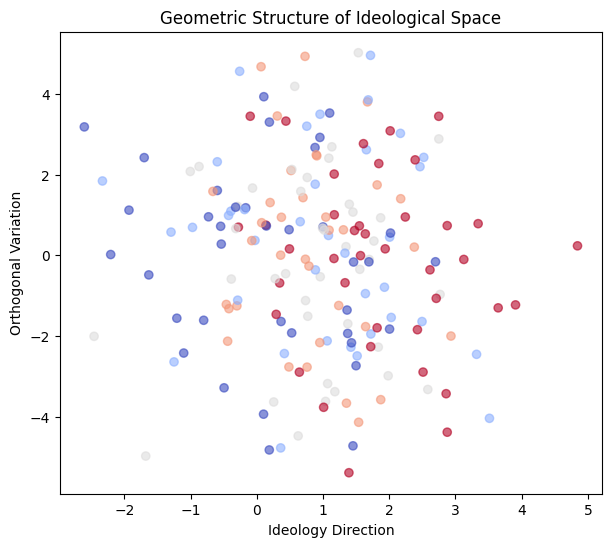

In [21]:
# -----------
# Visualize!
# -----------

plt.figure(figsize=(7,6))

plt.scatter(
    ideology_axis,
    orthogonal[:,0],
    c=y_labels_numeric,
    cmap="coolwarm",
    alpha=0.6
)

plt.xlabel("Ideology Direction")
plt.ylabel("Orthogonal Variation")
plt.title("Geometric Structure of Ideological Space")

plt.show()

# Wasserstein
- Now, we measure wasserstein distance (a popular component of GAN analysis) to see how ideology cluster shapes/geometry differ.
- To best explain wasserstein distance, we use the concept from computer science, known as earth's movers distance:


> "Wassersteun distance is a distance function defined between probability distributions on a given metric space. If each distribution is viewed as a unit amount of earth piled on *M*, the metric is the minimum "cost" of turning one pile into the other, which is assumed to be the amount of earth that needs to be moved times the mean distance it has to be moved."

- So we can see the difference between ideology distributions across the embedding space.
- We use `wasserstein_distance` function from the `scipy` package. But the function is essentially:

  $$
  D_{ij} = W_1({v^Tx|y=i}, {v^Tx|y=j})
  $$


where $D_{ij}$ is the distance between ideology groups i and j, $W_1$ is a 1D wasserstein distance, $v^Tx$ is a scalar ideology score for ideology i and j.

In [22]:
p_left = projections[y_test_bias == 'left']
p_ll = projections[y_test_bias == 'leaning-left']
p_center = projections[y_test_bias == 'center']
p_lr = projections[y_test_bias == 'leaning-right']
p_right = projections[y_test_bias == 'right']

means = {
    "left": np.mean(p_left),
    "leaning-left": np.mean(p_ll),
    "center": np.mean(p_center),
    "leaning-right": np.mean(p_lr),
    "right": np.mean(p_right)
}

labels = ["left", "leaning-left", "center", "leaning-right", "right"]
groups = [p_left, p_ll, p_center, p_lr, p_right]

dist_matrix = np.zeros((5,5))

for i, a in enumerate(groups):
    for j, b in enumerate(groups):
        dist_matrix[i,j] = wasserstein_distance(a, b)

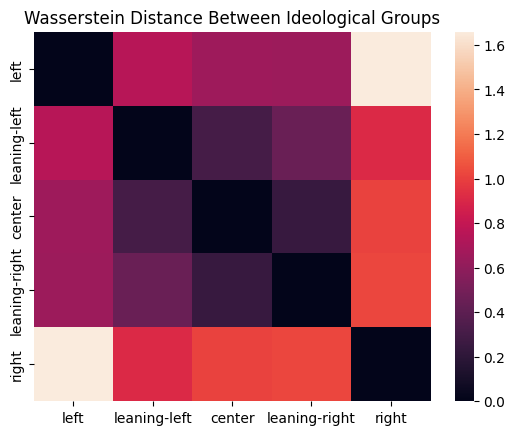

In [23]:
# -----------
# Visualize!
# -----------

sns.heatmap(dist_matrix, xticklabels=labels, yticklabels=labels)
plt.title("Wasserstein Distance Between Ideological Groups")
plt.show()

# KDE - Overap Projections
- Lastly, we use Kernsel Density Estimation to visualize both the shape of projection distributions and the overlap of those projections by ideology class.
- KDE estimates the probability density function of a set of data points by applying a smooth kernel (Gaussian) on each observation and summing these to produce a continuous distribution.
- KDE is particularly useful for small datasets.
- We compute KDE for each ideology class using the `kdeplot` function from the `seaborn` package, which represent an estimated probability distribution of ideology scores for that class.
- These scores come from projecting embeddings, so each KDE surve represents the distribution of ideological similarity within a class.



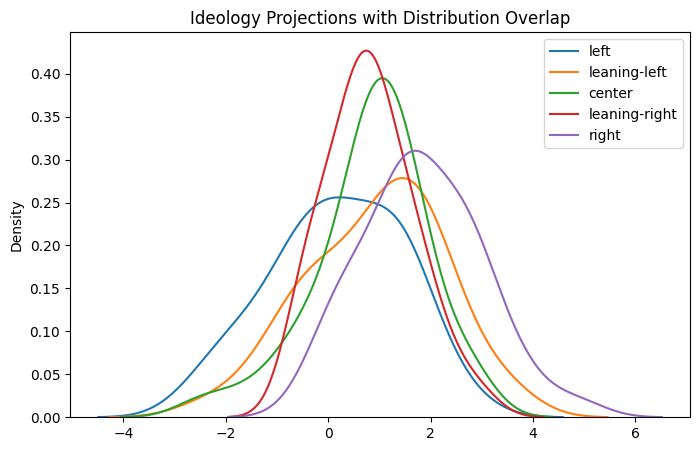

In [24]:
# -----------
# Visualize!
# -----------

plt.figure(figsize=(8,5))

sns.kdeplot(p_left, label="left")
sns.kdeplot(p_ll, label="leaning-left")
sns.kdeplot(p_center, label="center")
sns.kdeplot(p_lr, label="leaning-right")
sns.kdeplot(p_right, label="right")

plt.title("Ideology Projections with Distribution Overlap")
plt.legend()
plt.show()

# Layerwise Ideological Distribution - 3D

- We include a 3D representation of how ideological structure evolves through the transformer encoder
- We take the same projections for each layer, then covert into a frequency distribution of discrete ideology bins.

In [25]:
layer_bins = []

for l in range(13):
    X = val_layers[l]
    p = X @ v
    layer_bins.append(p)

all_vals = np.concatenate(layer_bins)
bins = np.linspace(all_vals.min(), all_vals.max(), 40)

hist_matrix = []

for p in layer_bins:
    hist, _ = np.histogram(p, bins=bins)
    hist_matrix.append(hist)

hist_matrix = np.array(hist_matrix)

X, Y = np.meshgrid(bins[:-1], np.arange(len(layer_bins)))

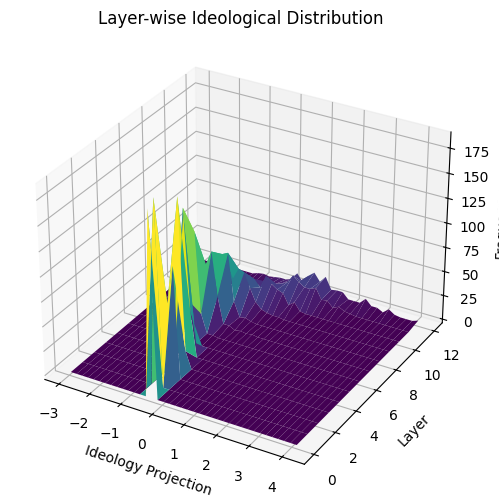

In [26]:
# -----------
# Visualize!
# -----------

fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(X, Y, hist_matrix, cmap='viridis')

ax.set_xlabel("Ideology Projection")
ax.set_ylabel("Layer")
ax.set_zlabel("Frequency")

plt.title("Layer-wise Ideological Distribution")
plt.show()